# To display availability amrices and their carbon footprint

(CVXPY) Jan 09 11:42:15 AM: Encountered unexpected exception importing solver MPAX:
RuntimeError('This version of jaxlib was built using AVX instructions, which your CPU and/or operating system do not support. You may be able work around this issue by building jaxlib from source.')


x -------------------- x
---> CB:  1
target carbon budget:  7.980065999999999
x --- x
problem 1 alpha fair: 


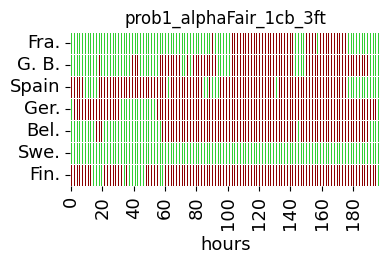

result:  7.973963999999996
x --- x
problem 2 CAFE: 


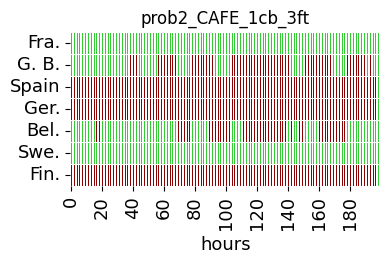

result:  7.969559999999998
x --- x
problem 3 fedzero: 


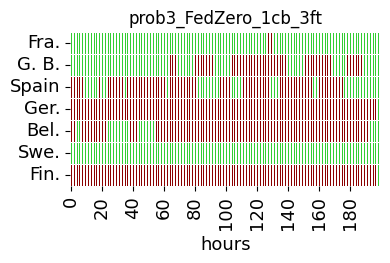

result:  7.975748999999998
x -------------------- x
---> CB:  2
target carbon budget:  6.1960109999999995
x --- x
problem 1 alpha fair: 


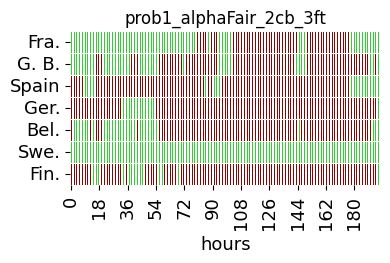

result:  6.1894499999999955
x --- x
problem 2 CAFE: 


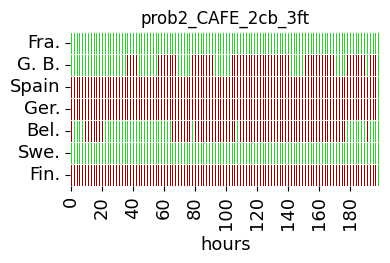

result:  6.190692000000001
x --- x
problem 3 fedzero: 


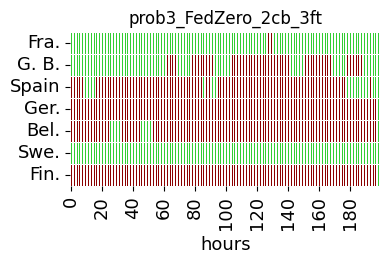

result:  6.181278000000001
x -------------------- x
---> CB:  3
target carbon budget:  4.235079
x --- x
problem 1 alpha fair: 


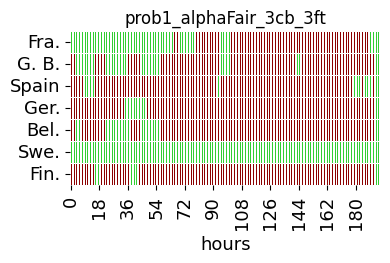

result:  4.229078999999999
x --- x
problem 2 CAFE: 


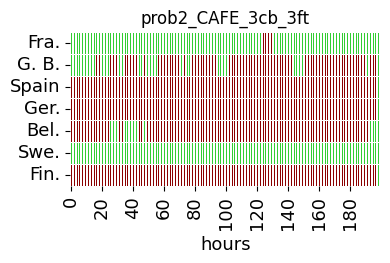

result:  4.2348029999999985
x --- x
problem 3 fedzero: 


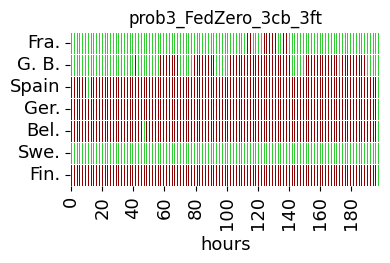

result:  4.234847999999999
x -------------------- x
---> CB:  4
target carbon budget:  1.983414
x --- x
problem 1 alpha fair: 


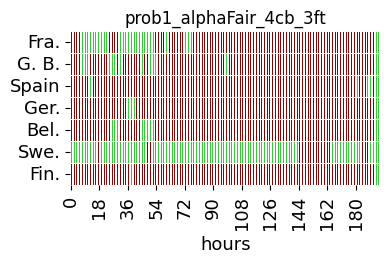

result:  1.9821
x --- x
problem 2 CAFE: 


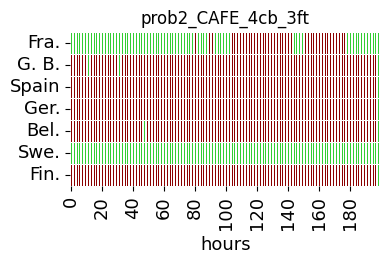

result:  1.9715909999999999
x --- x
problem 3 fedzero: 


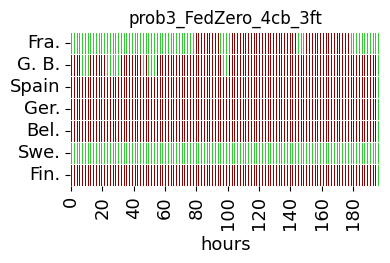

result:  1.9816200000000017
x -------------------- x
---> CB:  5
target carbon budget:  1.773765
x --- x
problem 1 alpha fair: 


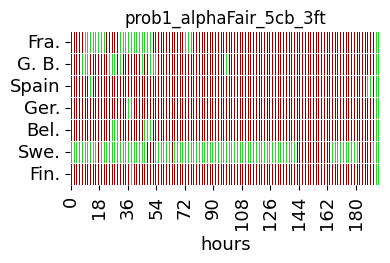

result:  1.7724690000000003
x --- x
problem 2 CAFE: 


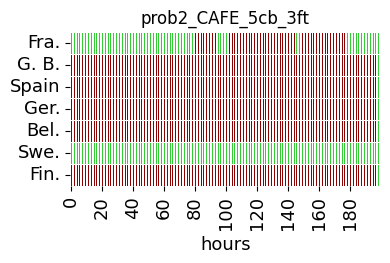

result:  1.7632979999999991
x --- x
problem 3 fedzero: 


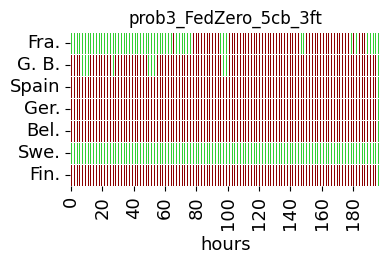

result:  1.7717339999999995
x -------------------- x
---> CB:  6
target carbon budget:  0.9428550000000001
x --- x
problem 1 alpha fair: 


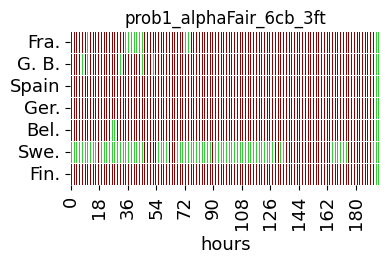

result:  0.9421020000000004
x --- x
problem 2 CAFE: 


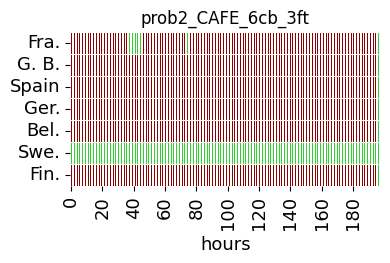

result:  0.9386490000000001
x --- x
problem 3 fedzero: 


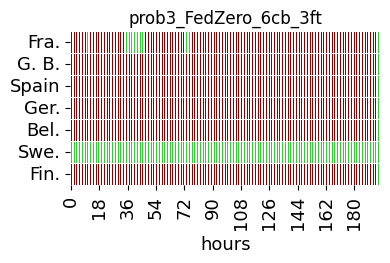

result:  0.940218
x -------------------- x
---> CB:  7
target carbon budget:  0.7447260000000001
x --- x
problem 1 alpha fair: 


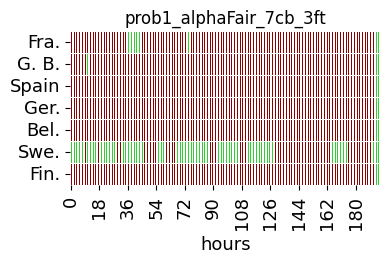

result:  0.7444380000000002
x --- x
problem 2 CAFE: 


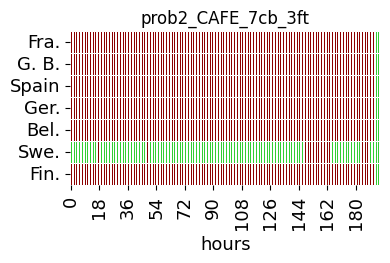

result:  0.7433070000000002
x --- x
problem 3 fedzero: 


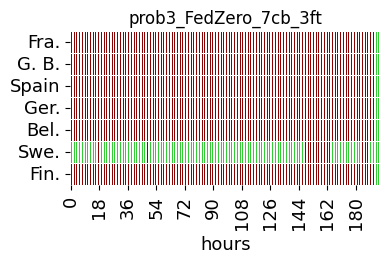

result:  0.7433070000000002


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from  matplotlib.colors import LinearSegmentedColormap
import sys
import os
_path = '..'
sys.path.append(os.path.join(_path))
from building_availability_matrices.av_mat_generation.CI_based.window import Window  # type: ignore

import argparse
from datetime import datetime
from typing import List, Optional, Tuple
def parse_start_time(s: Optional[str]) -> Optional[datetime]:
    if s is None:
        return None
    ss = s.strip().replace(" ", "T")
    try:
        return datetime.fromisoformat(ss)
    except Exception as e:
        raise ValueError(f"Could not parse --start-time '{s}'. Use ISO like '2022-01-01T00:00:00'.") from e
    
def parse_countries(countries_arg: str) -> List[str]:
    return [c.strip() for c in countries_arg.split(",") if c.strip()]

def load_ghg_matrix(horizon, start_time, countries: List[str]) -> Tuple[np.ndarray, List[str]]:
    """Load the carbon-intensity matrix ``g_c^t`` and associated labels."""

    window = Window(
        start_time=parse_start_time(start_time),
        random_start=False,
        out_folder=".",
        n_rounds=horizon,
        countries=parse_countries(countries),
    )

    ghg_dataframe = window.get_GHG_matrix()
    row_labels = list(ghg_dataframe.index) if hasattr(ghg_dataframe, "index") else list(countries)
    ghg_matrix = ghg_dataframe.to_numpy(dtype=float) if hasattr(ghg_dataframe, "to_numpy") else np.asarray(ghg_dataframe, dtype=float)

    if not np.isfinite(ghg_matrix).all():
        raise ValueError("GHG matrix contains NaNs/Infs. Check CI data parsing.")
    # return ghg_matrix, row_labels
    return ghg_dataframe

def plot_av_mat(av_mat_name, folder, av_mat_folder=""):
    """
    Plot heatmap of availability matrix (countries x datetime list).
    Green: available, Red: not available.
    """

    if len(av_mat_folder)>0:
        _path = "../availability_matrices/"+av_mat_folder+"/av-mat_"+av_mat_name+".csv"
    else:
        _path = "../availability_matrices/av-mat_"+av_mat_name+".csv"

    # if len(av_mat_folder)>0:
    #     _path = "../availability_matrices_baselines/"+av_mat_folder+"/av-mat__"+av_mat_name+".csv"
    # else:
    #     _path = "../availability_matrices_baselines/av-mat__"+av_mat_name+".csv"

    df = pd.DataFrame(pd.read_csv(_path, index_col=[0]))
    df.columns=[i for i in range(df.shape[1])]
    df.rename(index={'Belgium': 'Bel.', 'Great Britain': 'G. B.', 'Ireland': 'Ire.', 'Germany':'Ger.', 'France':'Fra.', 'Finland':'Fin.', 'Sweden':'Swe.'}, inplace=True)

    plt.figure(figsize=(4, 2))
    ax = plt.subplot()

    cmap = LinearSegmentedColormap.from_list("rwg", ["darkred", "limegreen"], N=2)
    sns.heatmap(df.astype(int), annot=False, fmt='d', cbar=False, cmap=cmap, linewidths=0.5, linecolor='white', ax=ax) # create heatmap

    if not isinstance(df.columns[0], np.int64):
        plt.xticks(rotation=45, ha='right')  # rotate x-axis labels to diagonal
    xticks = ax.get_xticks()
    xticks = xticks[::2]
    ax.set_xticks(xticks) # set new xticks
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    

    plt.xlabel("hours", fontsize=13)

    plt.title(av_mat_name)
    # plt.title("alpha 1.0")

    # plt.savefig('figures/'+folder+'/'+av_mat_name+'.png', bbox_inches='tight')
    plt.show()
    return df

   

countries="France,Great Britain,Spain,Germany,Belgium,Sweden,Finland"

_3FT_CB = [7.980065999999999,6.1960109999999995,4.235079,1.983414,1.773765,0.9428550000000001,0.7447260000000001]
iii=0
T=50
t_sl=150
horizon = T + t_sl
start_time="2022-01-01T00:00:00"
GHG_matrix = load_ghg_matrix(horizon, start_time, countries)
for cb in ["1", "2", "3", "4", "5", "6", "7"]:
    print("x -------------------- x")
    print("---> CB: ", cb)
    print("target carbon budget: ", _3FT_CB[iii])

    print("x --- x")
    print("problem 1 alpha fair: ")
    av_mat_name = "prob1_alphaFair_"+ cb + "cb_3ft"
    av_mat_df=plot_av_mat(av_mat_name, "baselines_check")
    # plot_av_mat("alphaF50-200sl-9cb-3ft", "baselines_check") 
    print(
        "result: ",
        np.sum(np.multiply(GHG_matrix.to_numpy()[:, :av_mat_df.shape[1]], av_mat_df.to_numpy())),
    )

    print("x --- x")
    print("problem 2 CAFE: ")
    av_mat_name = "prob2_CAFE_"+ cb + "cb_3ft"
    av_mat_df=plot_av_mat(av_mat_name, "baselines_check")
    print(
        "result: ",
        np.sum(np.multiply(GHG_matrix.to_numpy()[:, :av_mat_df.shape[1]], av_mat_df.to_numpy())),
    )

    print("x --- x")
    print("problem 3 fedzero: ")
    av_mat_name = "prob3_FedZero_"+ cb + "cb_3ft"
    av_mat_df=plot_av_mat(av_mat_name, "baselines_check")
    print(
        "result: ",
        np.sum(np.multiply(GHG_matrix.to_numpy()[:, :av_mat_df.shape[1]], av_mat_df.to_numpy())),
    )
    iii+=1

